# Projeto Original — Fine-tuning com RoBERTa-base

**Ciclo de divergência: `MODEL` (abordagem de alto desempenho).**

Os notebooks anteriores compararam representações textuais (TF-IDF, BM25, BGE-large, BGE-M3) usando os embeddings **congelados** + classificador linear. Aqui mudamos o paradigma: fazemos o **fine-tuning** de um transformer especializado em classificação, o **RoBERTa-base**, que é o tipo de modelo que domina o estado da arte do IMDB (~96%).

Mantemos os mesmos dados e a mesma divisão treino/teste dos outros notebooks, para que o F1 macro seja comparável.

### Duas camadas de análise

1. **Fine-tuning E2E (Trainer)** — todos os pesos do transformer são ajustados à tarefa; a cabeça de classificação é uma camada linear treinada junto. É a abordagem de referência.
2. **Classificadores sobre embeddings fine-tunados** — após o fine-tuning, extraímos o vetor `[CLS]` da última camada oculta e avaliamos os **4 classificadores clássicos** (SVM linear, Regressão Logística, Naive Bayes e Árvore de Decisão) sobre essa representação já ajustada. Isso responde: *a cabeça linear do Trainer é realmente a melhor forma de aproveitar os embeddings fine-tunados?*


## Dependências

In [1]:
!pip install -q transformers accelerate scikit-learn imbalanced-learn pandas

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

sns.set_style('darkgrid')
plt.rc('axes', titlesize=14)
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
plt.rc('legend', fontsize=11)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: cuda


## Configuração

`N_PER_CLASS` controla a escala (10000 reproduz o run de 20k). `MAX_LEN` é o limite de tokens (RoBERTa aceita até 512; 256 é mais rápido e suficiente para a maioria das críticas).

In [3]:
MODEL_NAME = 'roberta-base'
RANDOM_STATE = 42
N_PER_CLASS = 10000   # 10000/10000 = 20.000 registros
MAX_LEN = 512         # aumente para 512 para o melhor desempenho (mais lento)
EPOCHS = 3
BATCH = 8
LR = 2e-5

## Dados


In [4]:
candidates = ['IMDB Dataset.csv', '/content/IMDB Dataset.csv', '../IMDB Dataset.csv']
csv_path = next((p for p in candidates if os.path.exists(p)), None)

if csv_path is None:
    try:
        from google.colab import files
        print('Faça upload do IMDB Dataset.csv:')
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError('IMDB Dataset.csv não encontrado. Faça upload para /content.')

df_review = pd.read_csv(csv_path)
print('Total de linhas no CSV:', len(df_review))
df_review.head()

Total de linhas no CSV: 50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Sanidade: confirma que o CSV veio inteiro (pega upload truncado).
assert len(df_review) == 50000, f'Esperado 50000 linhas, veio {len(df_review)} — arquivo truncado?'

# Mesma amostragem do notebook "Original, 10k dados" para comparabilidade direta:
# remove reviews duplicadas (evita vazamento treino/teste) e tira amostra
# balanceada aleatória e reprodutível (mesmo RANDOM_STATE).
df_dedup = df_review.drop_duplicates(subset=['review'])
df_review_bal = (
    df_dedup.groupby('sentiment', group_keys=False)
    .sample(n=N_PER_CLASS, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
print(df_review_bal.value_counts('sentiment'))

# Mesma divisão treino/teste (mesmo random_state, sem stratify) -> mesmo conjunto de teste.
train_df, test_df = train_test_split(
    df_review_bal, test_size=0.33, random_state=RANDOM_STATE
)
# Rótulos numéricos para o RoBERTa (negative=0, positive=1).
train_df = train_df.assign(label=(train_df['sentiment'] == 'positive').astype(int))
test_df = test_df.assign(label=(test_df['sentiment'] == 'positive').astype(int))

print('Treino:', len(train_df), '| Teste:', len(test_df))
print(train_df['sentiment'].value_counts())

sentiment
negative    10000
positive    10000
Name: count, dtype: int64
Treino: 13400 | Teste: 6600
sentiment
positive    6729
negative    6671
Name: count, dtype: int64


## Tokenização

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_enc = tokenizer(list(train_df['review']), truncation=True, max_length=MAX_LEN)
test_enc = tokenizer(list(test_df['review']), truncation=True, max_length=MAX_LEN)

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_ds = IMDbDataset(train_enc, train_df['label'])
test_ds = IMDbDataset(test_enc, test_df['label'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## Modelo e Trainer

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

args = TrainingArguments(
    output_dir='roberta_imdb',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=32,
    learning_rate=LR,
    fp16=(DEVICE == 'cuda'),
    logging_steps=50,
    report_to='none',
)

collator = DataCollatorWithPadding(tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Treinamento (fine-tuning)

In [8]:
trainer.train()

Step,Training Loss
50,0.663028
100,0.401729
150,0.405403
200,0.304888
250,0.320570
300,0.413489
350,0.313376
400,0.323700
450,0.359768
500,0.379596


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5025, training_loss=0.19001904594364452, metrics={'train_runtime': 1888.8671, 'train_samples_per_second': 21.283, 'train_steps_per_second': 2.66, 'total_flos': 9808743143828640.0, 'train_loss': 0.19001904594364452, 'epoch': 3.0})

## Avaliação

In [9]:
RESULTS = []  # acumula todos os resultados para o COMMUNICATE

pred = trainer.predict(test_ds)
y_pred_e2e = np.argmax(pred.predictions, axis=-1)
y_true = test_df['label'].values

acc_e2e = accuracy_score(y_true, y_pred_e2e)
f1m_e2e = f1_score(y_true, y_pred_e2e, average='macro')

RESULTS.append({
    'Classificador': 'Linear Head (E2E)',
    'Tipo': 'Fine-tuning E2E',
    'Acurácia': acc_e2e,
    'F1 macro': f1m_e2e,
})

print('=== RoBERTa-base (fine-tuning E2E — Linear Head) ===')
print(f'Acurácia: {acc_e2e:.4f} | F1 macro: {f1m_e2e:.4f}')
print()
print(classification_report(y_true, y_pred_e2e, target_names=['negative', 'positive']))
print('Matriz de confusão (linhas=real, colunas=previsto) [negative, positive]:')
print(confusion_matrix(y_true, y_pred_e2e))


=== RoBERTa-base (fine-tuning E2E — Linear Head) ===
Acurácia: 0.9503 | F1 macro: 0.9503

              precision    recall  f1-score   support

    negative       0.96      0.94      0.95      3329
    positive       0.94      0.96      0.95      3271

    accuracy                           0.95      6600
   macro avg       0.95      0.95      0.95      6600
weighted avg       0.95      0.95      0.95      6600

Matriz de confusão (linhas=real, colunas=previsto) [negative, positive]:
[[3144  185]
 [ 143 3128]]


## Classificadores sobre embeddings fine-tunados

O encoder fine-tunado aprendeu uma representação densa orientada à tarefa. Extraímos o vetor `[CLS]` da **última camada oculta** — o mesmo sinal que a cabeça linear do Trainer usa internamente — e avaliamos os **4 classificadores clássicos** sobre ele.

Isso responde uma pergunta relevante: *o fine-tuning "enriquece" o espaço de features o suficiente para que até um Naive Bayes ou uma Árvore de Decisão consigam um bom desempenho? Ou a cabeça linear do Trainer é insubstituível?*

> **Nota técnica:** usamos `output_hidden_states=True` para acessar a última camada oculta de forma agnóstica à arquitetura. O vetor `[CLS]` (posição 0) tem dimensão 768 para o `roberta-base`.


In [11]:
def extract_cls_embeddings(dataset, batch_size=32):
    """Extrai o vetor [CLS] da última camada oculta do encoder fine-tunado.

    Usa o mesmo DataCollatorWithPadding do Trainer para garantir que sequências
    de comprimentos diferentes sejam padded antes do stack — sem isso o
    DataLoader padrão levanta RuntimeError ao tentar empilhar tensores desiguais.
    """
    model.eval()
    embeddings = []
    # collator já definido acima: DataCollatorWithPadding(tokenizer)
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, collate_fn=collator
    )
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask, output_hidden_states=True)
            cls  = out.hidden_states[-1][:, 0, :].cpu().numpy()  # [CLS] token
            embeddings.append(cls)
    return np.vstack(embeddings)

print('Extraindo embeddings fine-tunados do conjunto de treino...')
X_train_emb = extract_cls_embeddings(train_ds)
print('Extraindo embeddings fine-tunados do conjunto de teste...')
X_test_emb  = extract_cls_embeddings(test_ds)
print(f'Shape dos embeddings: {X_train_emb.shape}  (exemplos × dimensão)')

Extraindo embeddings fine-tunados do conjunto de treino...
Extraindo embeddings fine-tunados do conjunto de teste...
Shape dos embeddings: (13400, 768)  (exemplos × dimensão)


In [12]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

CLF_ORDER = ['SVM (linear)', 'LogReg', 'Naive Bayes', 'Decision Tree']

probe_models = {
    'SVM (linear)':  SVC(kernel='linear', C=1),
    'LogReg':        LogisticRegression(max_iter=1000),
    'Naive Bayes':   GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}

y_tr = train_df['label'].values
y_te = test_df['label'].values

for clf_name, clf in probe_models.items():
    clf.fit(X_train_emb, y_tr)
    y_pred_probe = clf.predict(X_test_emb)
    acc_p = accuracy_score(y_te, y_pred_probe)
    f1m_p = f1_score(y_te, y_pred_probe, average='macro')
    RESULTS.append({
        'Classificador': clf_name,
        'Tipo': 'Fine-tuned features',
        'Acurácia': acc_p,
        'F1 macro': f1m_p,
    })
    print(f'\n=== RoBERTa fine-tuned features — {clf_name} ===')
    print(f'Acurácia: {acc_p:.4f} | F1 macro: {f1m_p:.4f}')
    print(classification_report(y_te, y_pred_probe, target_names=['negative', 'positive']))



=== RoBERTa fine-tuned features — SVM (linear) ===
Acurácia: 0.9491 | F1 macro: 0.9491
              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      3329
    positive       0.94      0.95      0.95      3271

    accuracy                           0.95      6600
   macro avg       0.95      0.95      0.95      6600
weighted avg       0.95      0.95      0.95      6600


=== RoBERTa fine-tuned features — LogReg ===
Acurácia: 0.9482 | F1 macro: 0.9482
              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      3329
    positive       0.94      0.95      0.95      3271

    accuracy                           0.95      6600
   macro avg       0.95      0.95      0.95      6600
weighted avg       0.95      0.95      0.95      6600


=== RoBERTa fine-tuned features — Naive Bayes ===
Acurácia: 0.9502 | F1 macro: 0.9502
              precision    recall  f1-score   support

    negative       0.96      0.95 

# COMMUNICATE — Comparação dos resultados

Confrontamos o **fine-tuning E2E** (cabeça linear treinada junto com o encoder) com os **4 classificadores clássicos** aplicados sobre os embeddings `[CLS]` já ajustados.

- A tabela mostra todas as métricas ordenadas por F1 macro.
- O gráfico de barras destaca visualmente a diferença entre as abordagens.


In [13]:
df_results = pd.DataFrame(RESULTS).sort_values('F1 macro', ascending=False).reset_index(drop=True)
df_results.style.format({'Acurácia': '{:.4f}', 'F1 macro': '{:.4f}'})\
          .background_gradient(subset=['F1 macro', 'Acurácia'], cmap='Greens')


,Classificador,Tipo,Acurácia,F1 macro
0,Linear Head (E2E),Fine-tuning E2E,0.9503,0.9503
1,Naive Bayes,Fine-tuned features,0.9502,0.9502
2,SVM (linear),Fine-tuned features,0.9491,0.9491
3,LogReg,Fine-tuned features,0.9482,0.9482
4,Decision Tree,Fine-tuned features,0.9430,0.9430


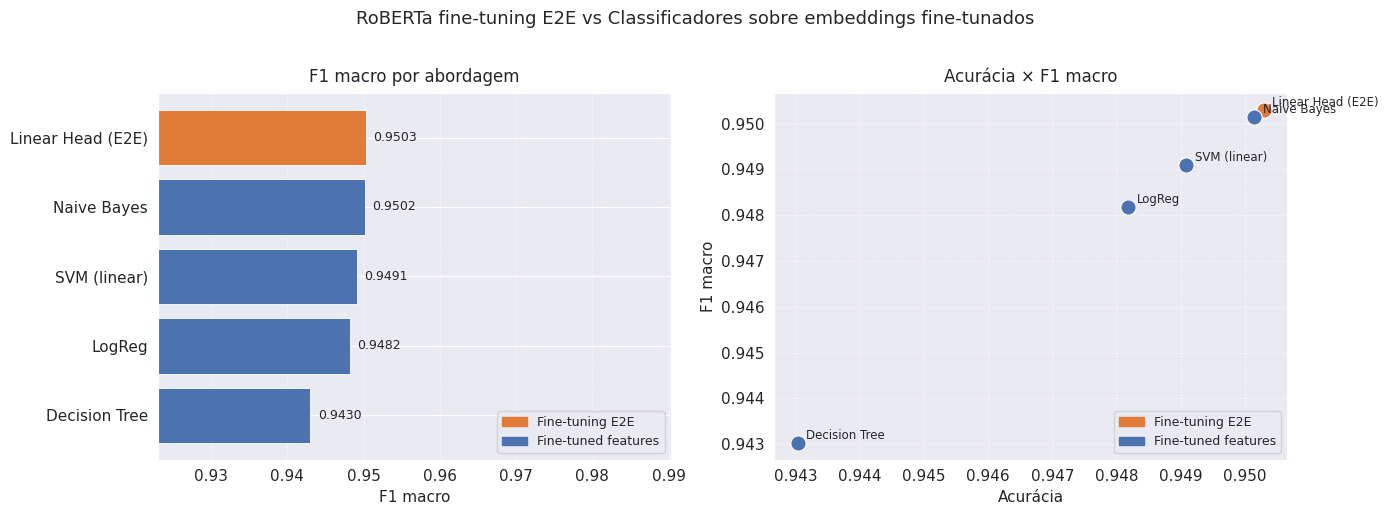


Melhor resultado geral: Linear Head (E2E) → F1 macro = 0.9503
   Fine-tuning E2E (Linear Head): F1 macro = 0.9503
   → Resultados equivalentes entre E2E e melhor probe.


In [15]:
CLF_ALL   = ['Linear Head (E2E)'] + CLF_ORDER
TIPO_COLOR = {'Fine-tuning E2E': '#e07b39', 'Fine-tuned features': '#4c72b0'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Painel esquerdo: barras ordenadas por F1 macro ────────────────────────────
ax1 = axes[0]
df_sorted = df_results.copy()
colors = [TIPO_COLOR[t] for t in df_sorted['Tipo']]
bars = ax1.barh(df_sorted['Classificador'], df_sorted['F1 macro'],
                color=colors, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, df_sorted['F1 macro']):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)
ax1.set_xlabel('F1 macro', fontsize=11)
ax1.set_title('F1 macro por abordagem', fontsize=12, pad=8)
ax1.set_xlim(df_sorted['F1 macro'].min() - 0.02, df_sorted['F1 macro'].max() + 0.04)
ax1.invert_yaxis()
ax1.xaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
# Legenda de tipo
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=t) for t, c in TIPO_COLOR.items()]
ax1.legend(handles=legend_handles, fontsize=9, loc='lower right')

# ── Painel direito: acurácia vs F1 macro (scatter) ───────────────────────────
ax2 = axes[1]
for _, row in df_results.iterrows():
    color = TIPO_COLOR[row['Tipo']]
    ax2.scatter(row['Acurácia'], row['F1 macro'], color=color, s=120, zorder=3,
                edgecolors='white', linewidths=0.8)
    ax2.annotate(
        row['Classificador'],
        xy=(row['Acurácia'], row['F1 macro']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=8.5
    )
ax2.set_xlabel('Acurácia', fontsize=11)
ax2.set_ylabel('F1 macro', fontsize=11)
ax2.set_title('Acurácia × F1 macro', fontsize=12, pad=8)
ax2.xaxis.grid(True, linestyle='--', alpha=0.5)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.legend(handles=legend_handles, fontsize=9, loc='lower right')

fig.suptitle(
    'RoBERTa fine-tuning E2E vs Classificadores sobre embeddings fine-tunados',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('comparacao_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumo textual ────────────────────────────────────────────────────────────
best = df_results.iloc[0]
e2e  = df_results[df_results['Tipo'] == 'Fine-tuning E2E'].iloc[0]
print(f'\nMelhor resultado geral: {best["Classificador"]} → F1 macro = {best["F1 macro"]:.4f}')
print(f'   Fine-tuning E2E (Linear Head): F1 macro = {e2e["F1 macro"]:.4f}')
gap = best['F1 macro'] - e2e['F1 macro']
if gap > 0.001:
    print(f'   → {best["Classificador"]} supera o E2E em +{gap:.4f}')
elif gap < -0.001:
    print(f'   → E2E supera o melhor probe em +{-gap:.4f}')
else:
    print('   → Resultados equivalentes entre E2E e melhor probe.')
